In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

url = "https://books.toscrape.com/"

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [3]:
# Scrape book details from the first page

soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")

data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text.strip()
    rating = book.find("p", class_="star-rating")["class"][1]
    availability = book.find("p", class_="instock").text.strip()

    data.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability
    })

df = pd.DataFrame(data)

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [4]:
# Scrape books from multiple pages

all_books = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    if response.status_code != 200:
        break

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text.strip()
        rating = book.find("p", class_="star-rating")["class"][1]
        availability = book.find("p", class_="instock").text.strip()

        all_books.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability
        })

df = pd.DataFrame(all_books)

print("Total books scraped:", len(df))

df.head()

Total books scraped: 1000


,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [7]:
# Clean and organize scraped data

# Convert price from text to numeric
df['Price'] = (
    df['Price']
    .str.replace('Â£', '', regex=False)
    .str.replace('£', '', regex=False)
    .str.strip()
    .astype(float)
)

# Convert ratings from words to numbers
rating_map = {
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4,
    'Five': 5
}

df['Rating'] = df['Rating'].map(rating_map)

# Clean availability text
df['Availability'] = (
    df['Availability']
    .str.replace('\n', ' ', regex=False)
    .str.strip()
)

# Remove duplicate books if any
df = df.drop_duplicates()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1000
Columns: 4


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [8]:
# Basic analysis of scraped book data

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df[['Price', 'Rating']].describe())

Dataset Shape: (1000, 4)

Missing Values:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64

Descriptive Statistics:
            Price       Rating
count  1000.00000  1000.000000
mean     35.07035     2.923000
std      14.44669     1.434967
min      10.00000     1.000000
25%      22.10750     2.000000
50%      35.98000     3.000000
75%      47.45750     4.000000
max      59.99000     5.000000


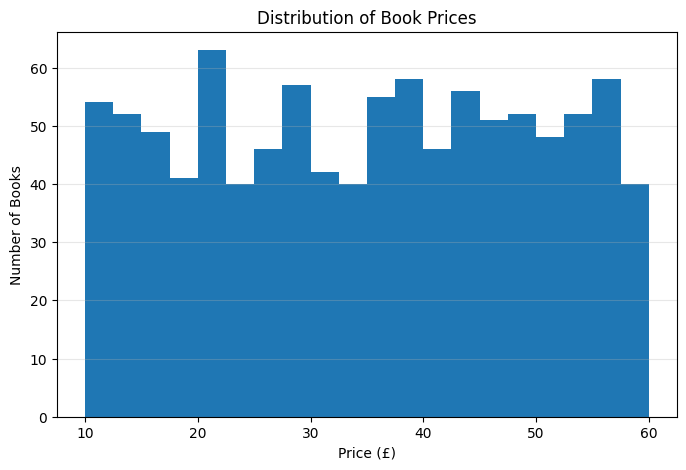

In [9]:
# Price Distribution of Books

plt.figure(figsize=(8, 5))

plt.hist(df['Price'], bins=20)

plt.title('Distribution of Book Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.grid(axis='y', alpha=0.3)

plt.show()

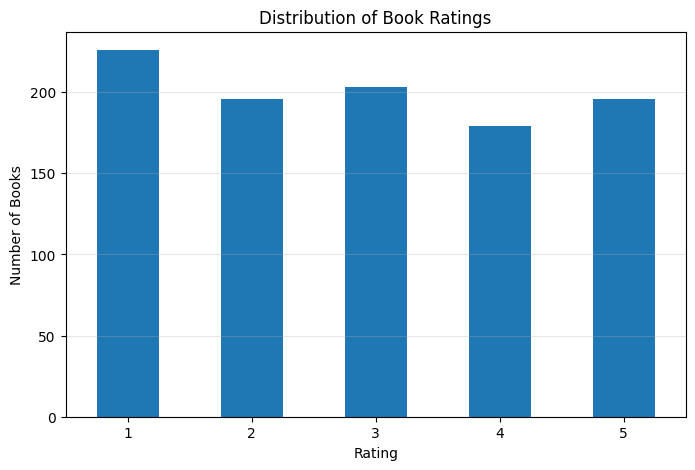

In [10]:
# Rating Distribution of Books

rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar')

plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Books')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

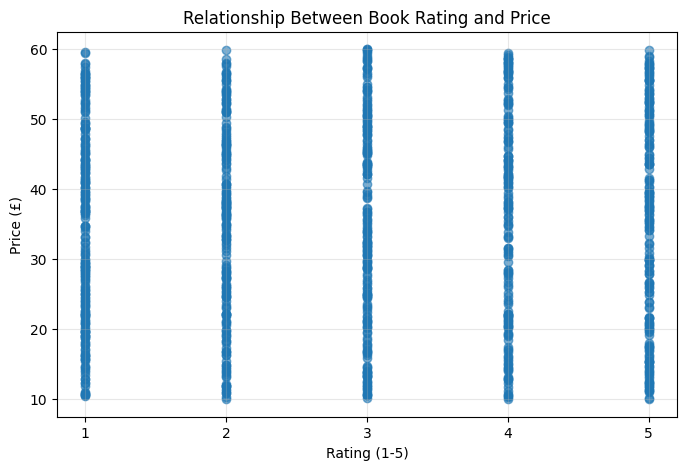

In [11]:
# Rating vs Price Relationship

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Rating'],
    df['Price'],
    alpha=0.6
)

plt.title('Relationship Between Book Rating and Price')
plt.xlabel('Rating (1-5)')
plt.ylabel('Price (£)')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
# Top 10 Most Expensive Books

top_10_expensive = df.nlargest(10, 'Price')[['Title', 'Price', 'Rating']]

top_10_expensive

,Title,Price,Rating
648,The Perfect Play (Play by Play #1),59.99,3
617,Last One Home (New Beginnings #1),59.98,3
860,Civilization and Its Discontents,59.95,2
560,The Barefoot Contessa Cookbook,59.92,5
366,The Diary of a Young Girl,59.90,3
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1
387,Boar Island (Anna Pigeon #19),59.48,3
393,The Improbability of Love,59.45,1
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4


In [13]:
# Top-Rated Books

top_rated = df[df['Rating'] == 5][['Title', 'Price', 'Rating']]

top_rated.head(10)

,Title,Price,Rating
4,Sapiens: A Brief History of Humankind,54.23,5
12,Set Me Free,17.46,5
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5
14,Rip it Up and Start Again,35.02,5
23,Chase Me (Paris Nights #2),25.27,5
24,Black Dust,34.53,5
28,Worlds Elsewhere: Journeys Around Shakespeareâ...,40.30,5
30,The Four Agreements: A Practical Guide to Pers...,17.66,5
32,The Elephant Tree,23.82,5
34,Sophie's World,15.94,5


# Task 5: Web Data Extraction & Analysis – Findings

## Web Scraping Summary

Book information was extracted from the Books to Scrape website using Python, Requests, and BeautifulSoup.

The scraping process was automated across multiple pages to collect book titles, prices, ratings, and availability information into a structured dataset.

## Data Processing

The scraped data was cleaned and converted into a structured Pandas DataFrame.

- Book prices were converted from text to numerical values.
- Ratings were converted from text values to numerical scores from 1 to 5.
- Availability information was cleaned.
- Duplicate records were removed.

## Key Findings

### 1. Book Price Distribution

The price distribution shows that most books fall within a relatively moderate price range, while some books have considerably higher prices.

### 2. Rating Distribution

The rating analysis shows that books have ratings ranging from 1 to 5 stars, with some rating levels occurring more frequently than others.

### 3. Rating vs Price

The scatter plot shows that book price varies across different rating levels. A higher rating does not necessarily mean that a book has a higher price.

### 4. Most Expensive Books

The analysis identified the top 10 most expensive books based on their listed prices.

### 5. Top-Rated Books

Books with a 5-star rating were identified to understand which products received the highest customer ratings.

## Business Insights

- Price and rating should be considered separately when evaluating books.
- Highly rated books can be highlighted in promotional campaigns.
- Expensive books can be targeted for premium product promotions.
- Combining price, rating, and availability can help businesses make better product decisions.
- Automated web scraping can help collect structured product information efficiently.

## Conclusion

This project demonstrates how web scraping can be used to collect publicly available product information and convert it into a structured dataset for analysis.

The extracted data was cleaned, analyzed, and visualized to identify pricing patterns, rating distributions, and potentially valuable products. The project also demonstrates how Python can automate the process of collecting and analyzing web data.

In [14]:
# Export scraped and cleaned data

df.to_csv("scraped_books.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!
